In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.integrate import solve_ivp

# Burger Equation Simulation


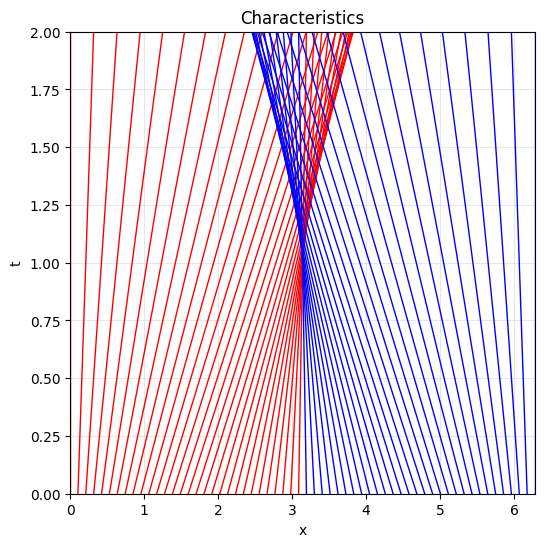

In [ ]:
# Parameters
Nx = 60   # number of characteristics
Nt = 400  # time steps
T = 2     # final time

x0_vals = np.linspace(0, 2*np.pi, Nx)
t_vals = np.linspace(0, T, Nt)

X = np.zeros((Nx, Nt))
# Computing characteristics
for i, x0 in enumerate(x0_vals):
    v0 = np.sin(x0)                 # velocity along characteristic
    X[i, :] = x0 + v0 * t_vals      # x(t) = x0 + v t

# Plot
plt.figure(figsize=(6, 6))
for i in range(Nx):
    c = 'b' if x0_vals[i] > np.pi else 'r'
    plt.plot(X[i, :], t_vals, color=c, linewidth=1)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Characteristics")
plt.xlim(0, 2*np.pi)
plt.ylim(0, T)
plt.grid(alpha=0.3)
plt.show()

## Velocity Profile plotted on Desmos

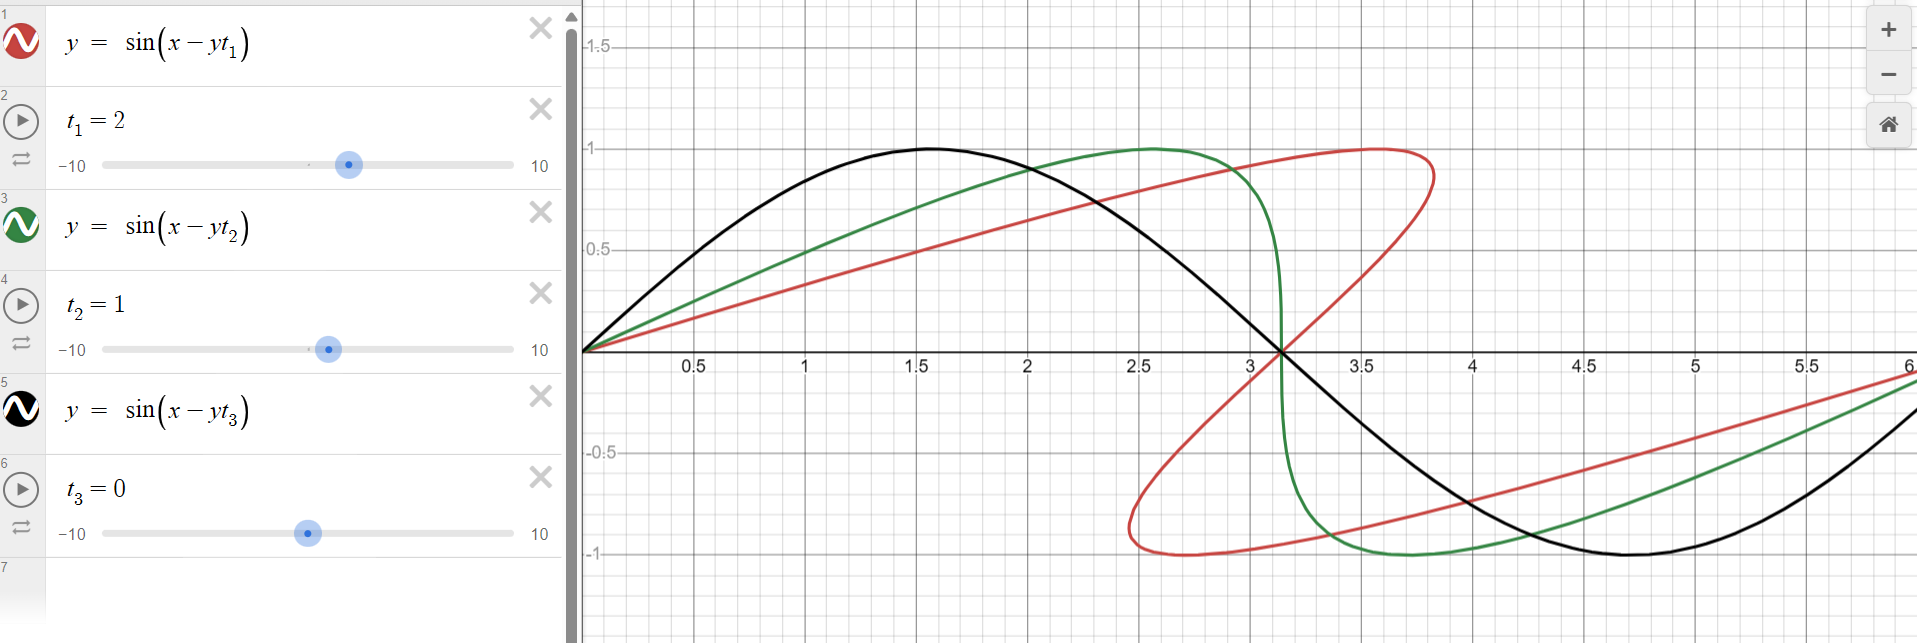

## Adding Viscosity

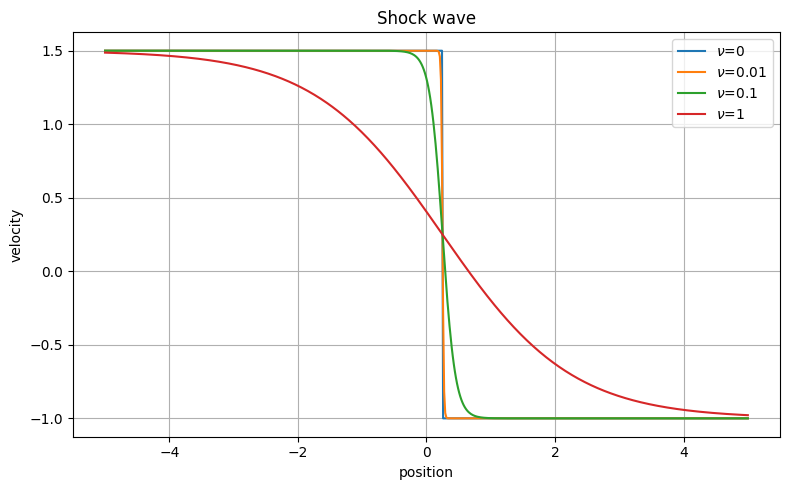

In [ ]:
# Domain
x = np.linspace(-5, 5, 600)
t = 1.0
etas = [0, 0.01, 0.1, 1]
vL_s, vR_s = 1.5, -1
S = (vL_s + vR_s)/2

def shock_solution(x, eta):
    if eta == 0:
        return np.where(x < S*t, vL_s, vR_s)
    return (vL_s + vR_s)/2 - (vL_s - vR_s)/2 * np.tanh((x - S*t)/(2*eta))

plt.figure(figsize=(8,5))
for eta in etas:
    plt.plot(x, shock_solution(x, eta), label=rf'$\nu$={eta}')
plt.title("Shock wave")
plt.xlabel("position")
plt.ylabel("velocity")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

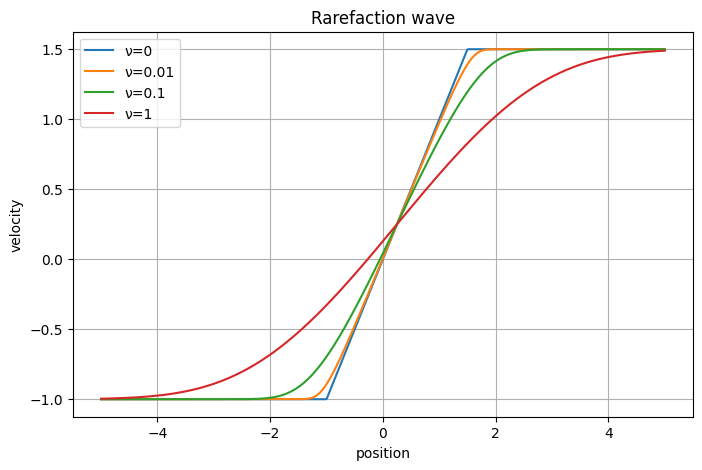

In [ ]:
# parameters
vL, vR = -1.0, 1.5
t = 1.0
x = np.linspace(-5, 5, 800)

def phi(x, t, nu):
    termL = np.exp(-vL*x/(2*nu) + vL**2 * t/(4*nu)) \
            * erfc((x - vL*t)/np.sqrt(4*nu*t))
    termR = np.exp(-vR*x/(2*nu) + vR**2 * t/(4*nu)) \
            * erfc((vR*t - x)/np.sqrt(4*nu*t))
    return termL + termR

def velocity(x, t, nu):
    if nu == 0:
        v = np.zeros_like(x)
        v[x < vL*t] = vL
        v[x > vR*t] = vR
        mask = (x >= vL*t) & (x <= vR*t)
        v[mask] = x[mask]/t
        return v
    phi_val = phi(x, t, nu)
    log_phi = np.log(phi_val)
    dlogphi_dx = np.gradient(log_phi, x)
    return -2*nu * dlogphi_dx

# plot
nus = [0, 0.01, 0.1, 1]
plt.figure(figsize=(8,5))
for nu in nus:
    v = velocity(x, t, nu)
    plt.plot(x, v, label=f'ν={nu}')
plt.xlabel("position")
plt.ylabel("velocity")
plt.title("Rarefaction wave")
plt.legend()
plt.grid()
plt.show()

## Sedov Solution

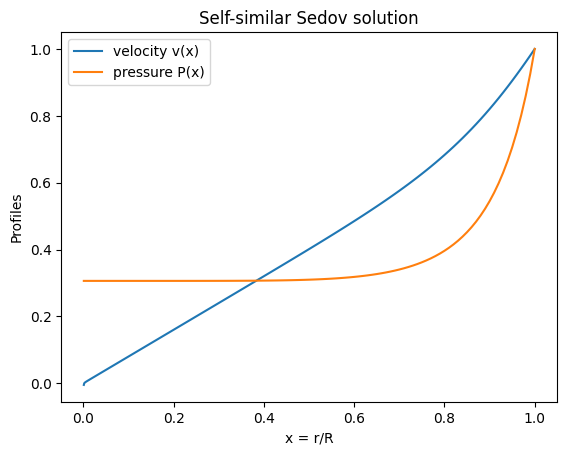

In [ ]:
A = 0.75 # A = 2/(\gamma + 1)
B = 1.25 # B = 2\gamma/(\gamma + 1)

def odes(x, y):
    p, v, P = y
    M = np.array([
        [A*v - x, A*p, 0],
        [0, p*(A*v - x), (B - 1)],
        [0, B*P, A*v - x]
    ])
    R = np.array([
        -2*A*p*v/x,
        1.5 *v*p,
        3*P - 2*B*P*v/x
    ])
    # Solving M * derivatives = R
    derivs = np.linalg.solve(M, R)
    dpdx, dvdx, dPdx = derivs
    return [dpdx, dvdx, dPdx]

# Initial conditions at shock
x_span = (1.0, 1e-3)  # integrate inward
y0 = [1.0, 1.0, 1.0]

sol = solve_ivp(odes,x_span,y0,method='Radau',dense_output=True,max_step=0.001)
x = sol.t
p = sol.y[0]
v = sol.y[1]
P = sol.y[2]

idx = np.argsort(x)
x = x[idx]
p = p[idx]
v = v[idx]
P = P[idx]

# Plot
plt.figure()
plt.plot(x, v, label='velocity v(x)')
plt.plot(x, P, label='pressure P(x)')
plt.xlabel('x = r/R')
plt.ylabel('Profiles')
plt.legend()
plt.title('Self-similar Sedov solution')
plt.show()

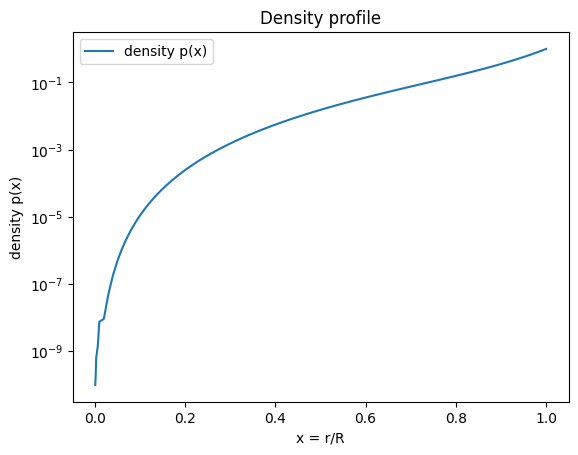

In [19]:
plt.plot(x, p, label='density p(x)')
plt.xlabel('x = r/R')
plt.ylabel('density p(x)')
plt.legend()
plt.yscale('log')
plt.title('Density profile')
plt.show()  

## With non-uniform density

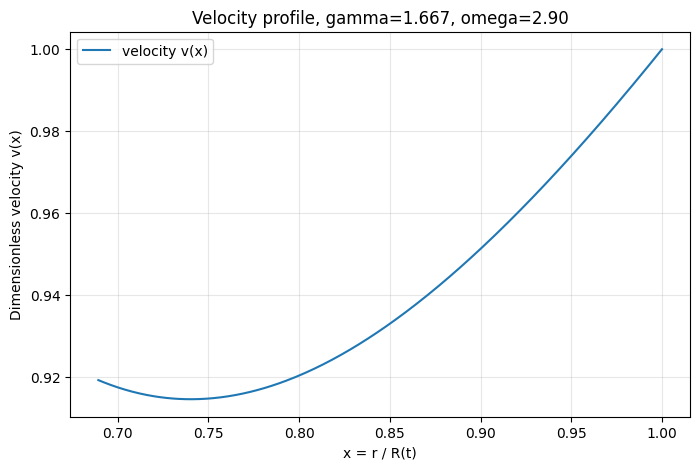

In [ ]:
def sedov_nonu(gamma=5/3, omega=0.0):
    m = 2.0 / (5.0 - omega)
    c = (m - 1.0) / m
    def odes(x, y):
        # y = [G, V, Z]
        G, V, Z = y
        M = np.array([
            [V - x,     G,        0.0],
            [0.0,       G*(V - x),     1.0],
            [0.0,   gamma * Z,     V - x]
        ], dtype=float)
        RHS = np.array([
            -(2-omega)*G*V/x,
            -c*V*G + Z*omega/x,
            Z*(3-omega - (2.0 * gamma - omega) * V / x )
        ], dtype=float)
        dGdx, dVdx, dZdx = np.linalg.solve(M, RHS)
        return [dGdx, dVdx, dZdx]

    G1 = (gamma + 1.0) / (gamma - 1.0) # Scaled Density
    V1 = 2.0 / (gamma + 1.0)  # Scaled Velocity
    Z1 = 2.0 / (gamma + 1.0) # Scaled Pressure

    y0 = [G1, V1, Z1]
    x_span = (1.0, 1e-3)  # integrate inward
    sol = solve_ivp(odes,x_span, y0,method='Radau',dense_output=True,max_step=0.001,rtol=1e-8, atol=1e-10)
    x = sol.t
    G, V, Z = sol.y

    idx = np.argsort(x)
    x = x[idx]
    G = G[idx]
    V = V[idx]
    Z = Z[idx]
    return x, G/G1, V/V1, Z/Z1, m, sol

gamma = 5/3
omega = 2.9

x, p,v,P, m, sol = sedov_nonu(gamma=gamma, omega=omega)

plt.figure(figsize=(8, 5))
plt.plot(x, v, label="velocity v(x)")
plt.xlabel("x = r / R(t)")
plt.ylabel("Dimensionless velocity v(x)")
plt.title(f"Velocity profile, gamma={gamma:.3f}, omega={omega:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

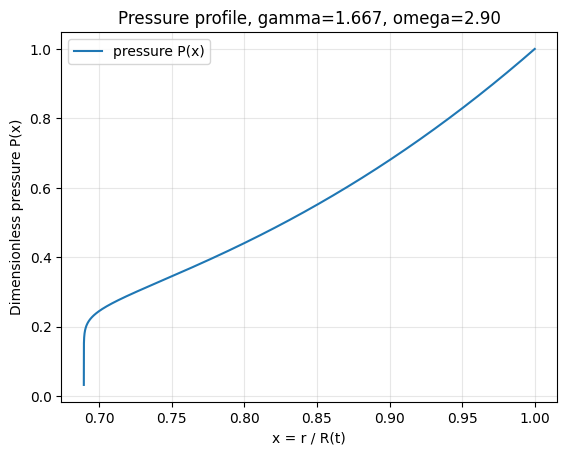

In [121]:
plt.plot(x, P, label="pressure P(x)")
plt.xlabel("x = r / R(t)")
plt.ylabel("Dimensionless pressure P(x)")
plt.title(f"Pressure profile, gamma={gamma:.3f}, omega={omega:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

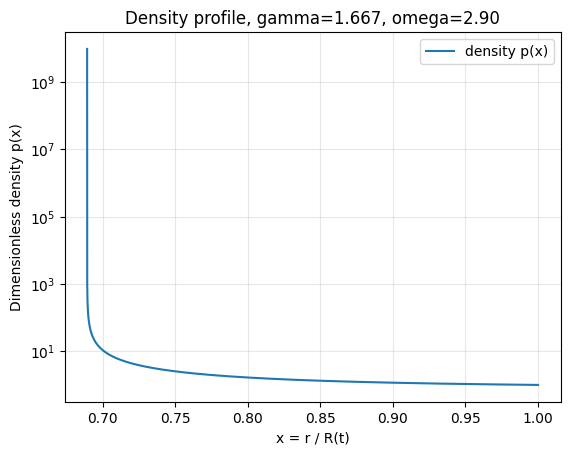

In [122]:
plt.plot(x, p, label="density p(x)")
plt.xlabel("x = r / R(t)")
plt.ylabel("Dimensionless density p(x)")
plt.title(f"Density profile, gamma={gamma:.3f}, omega={omega:.2f}")
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()